# Gen Python API Tutorial

We start off by initializing a new repository:


In [1]:
import gen

repo = gen.Repository()

This searches the current working directory for a `.gen` folder that holds the data and operations infrastructure. If no existing repository was found, a new .gen folder and database will be created.  You can also load a local repository that is outside of the present working directory by specifying the location of its .gen folder.

In [2]:
import tempfile
import pathlib
import gen

tmp = tempfile.TemporaryDirectory()
repo = gen.Repository(tmp.name)

gfa_path = pathlib.Path("../../fixtures/anderson_promoters.gfa").resolve()
repo.import_gfa(str(gfa_path))
print("Imported:", gfa_path)

Imported: /Users/bvh/git/gen/fixtures/anderson_promoters.gfa


The repository can be queried through methods like get_sequence_graphs() (recommended), or direct database access.

In [3]:
bgs = repo.get_sequence_graphs()
print(f"Number of sequence graphs: {len(bgs)}")

Number of sequence graphs: 1


In [4]:
result = repo.query("SELECT COUNT(*) FROM block_groups") 
print(f"Number of block groups: {result[0][0]}")

Number of block groups: 1


## Working with Graphs

Gen organizes genomic data in sequence graphs. Let's explore how to access and work with graphs.

### Interactive graph widget

`display(sequence_graph)` renders a navigable terminal-style graph viewer directly in the notebook, use the mouse to navigate.
You can also control the widget programatically for more control.

# Gen graph widget, frozen to a static image for GitHub viewing.
# The text below is an ASCII rendering of the same frame: each character is one
# terminal cell from the Rust layout engine; UPPERCASE marks a highlighted
# annotation region, lowercase is unhighlighted sequence/graph structure.
# To interact with this graph instead of reading the ASCII, rerun the notebook's
# own cell (e.g. `repo.plot(sg)` or `sample.plot()`) in a live Jupyter kernel; the
# returned GraphWidget supports .zoom_in()/.zoom_out(), .scroll_left()/.scroll_right()/
# .scroll_up()/.scroll_down(), and .next_page()/.prev_page() for multi-page samples.





       ╭─t─╮   ╭─t─╮   ╭─t─┬─a─╮            ╭─t─╮     ╭─a─╮
     ╟─┤   ├─t─┤   ├─a─┤   │   ├─gctagctcag─┤   ├─cct─┤   ├─
       ╰───╯   ╰─g─╯   ╰─c─┴─g─╯            ╰─c─╯     ╰─t─╯
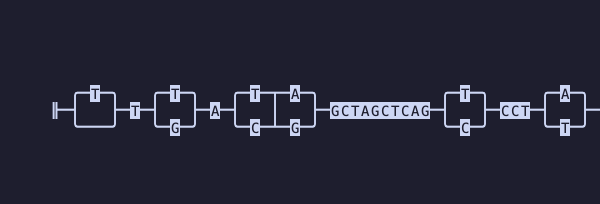

In [5]:
bgs = repo.get_sequence_graphs()
bg = bgs[0]

bg

## Networkx
Arguably the most popular graph library for Python

Converted to NetworkX graph with 28 nodes and 40 edges
Average node degree: 2.86


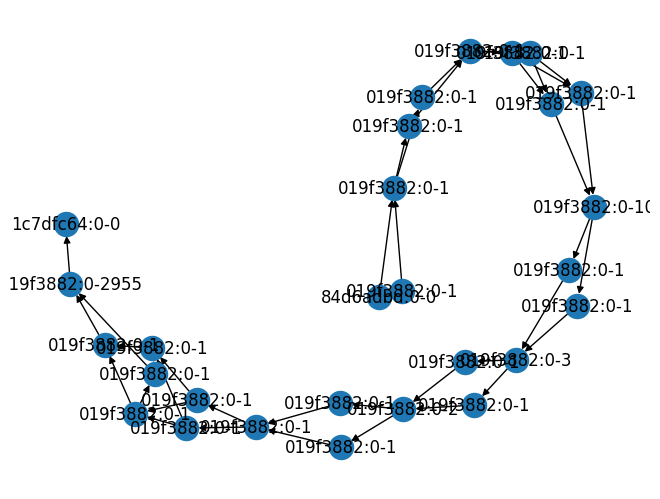

In [6]:
try:
    import networkx as nx
    import matplotlib.pyplot as plt

    nx_repr = bg.to_networkx()
    print(
        f"Converted to NetworkX graph with {nx_repr.number_of_nodes()} nodes and {nx_repr.number_of_edges()} edges"
    )

    # Analyze the graph
    if nx_repr.number_of_nodes() > 0:
        # Get node degrees
        degrees = [nx_repr.degree(n) for n in nx_repr.nodes()]
        avg_degree = sum(degrees) / len(degrees) if degrees else 0
        print(f"Average node degree: {avg_degree:.2f}")

    # Draw the graph
    plt.figure()
    nx.draw(nx_repr, with_labels=True)
    plt.show()

except ImportError:
    print("NetworkX not installed. Install with: pip install networkx")

## RustworkX
Similar to NetworkX but built on Rust under the hood.

In [7]:
try:
    import rustworkx as rx
    import rustworkx.visualization as rxv

    rx_repr = bg.to_rustworkx()

    display(rxv.graphviz_draw(rx_repr))

except ImportError:
    print("RustworkX not installed. Install with: pip install rustworkx")

RustworkX not installed. Install with: pip install rustworkx


## Dictionary

In [8]:
dict_repr = bg.to_dict()
print("Edges are keyed by (Node, Node) tuples:")
display(dict_repr["edges"])
print("Nodes:")
display(dict_repr["nodes"])

Edges are keyed by (Node, Node) tuples:


{(Node(019f3882[0:3]),
  Node(019f3882[0:1])): [{'edge_id': <HashId at 0x10df84af0>,
   'source_strand': '+',
   'target_strand': '+',
   'chromosome_index': -1,
   'phased': 0}],
 (Node(019f3882[0:1]),
  Node(019f3882[0:2])): [{'edge_id': <HashId at 0x10df86a70>,
   'source_strand': '+',
   'target_strand': '+',
   'chromosome_index': -1,
   'phased': 0}],
 (Node(019f3882[0:1]),
  Node(019f3882[0:1])): [{'edge_id': <HashId at 0x10df844b0>,
   'source_strand': '+',
   'target_strand': '+',
   'chromosome_index': -1,
   'phased': 0}],
 (Node(019f3882[0:1]),
  Node(019f3882[0:1])): [{'edge_id': <HashId at 0x10df85170>,
   'source_strand': '+',
   'target_strand': '+',
   'chromosome_index': -1,
   'phased': 0}],
 (Node(019f3882[0:10]),
  Node(019f3882[0:1])): [{'edge_id': <HashId at 0x10df85af0>,
   'source_strand': '+',
   'target_strand': '+',
   'chromosome_index': -1,
   'phased': 0}],
 (Node(019f3882[0:1]),
  Node(019f3882[0:3])): [{'edge_id': <HashId at 0x10a6687b0>,
   'source_str

Nodes:


[Node(019f3882[0:3]),
 Node(019f3882[0:1]),
 Node(019f3882[0:1]),
 Node(019f3882[0:1]),
 Node(019f3882[0:1]),
 Node(019f3882[0:1]),
 Node(019f3882[0:1]),
 Node(019f3882[0:1]),
 Node(019f3882[0:1]),
 Node(019f3882[0:1]),
 Node(019f3882[0:1]),
 Node(019f3882[0:1]),
 Node(019f3882[0:1]),
 Node(019f3882[0:1]),
 Node(019f3882[0:1]),
 Node(019f3882[0:1]),
 Node(019f3882[0:2]),
 Node(019f3882[0:1]),
 Node(019f3882[0:1]),
 Node(019f3882[0:1]),
 Node(019f3882[0:2955]),
 Node(019f3882[0:10]),
 Node(019f3882[0:1]),
 Node(019f3882[0:1]),
 Node(019f3882[0:1]),
 Node(019f3882[0:1]),
 Node(84d6adbd[0:0]),
 Node(1c7dfc64[0:0])]